# Nshift assignment analysis

Notebook solver-log style per output `tests/Nshift_speed/output/N*`.
Permette selezione `first_per_slot` / `last_per_slot` e usa la stessa funzione di plot di `solver_logs_analysis`.

In [19]:
%matplotlib inline
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)

# --- user options ---
SELECTED_N = 10
RUN_SELECTION_MODE = "first_per_slot"  # all | first_per_slot | last_per_slot | all_for_slot
TARGET_SLOT = None  # used only with all_for_slot

STRATEGY_COLORS = {
    "Fast": "#1f77b4",
    "Balanced": "#2ca02c",
    "Accurate": "#ff7f0e",
}

In [20]:
cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd.parent.parent]
online2_dir = next((p for p in candidates if (p / "tests" / "Nshift_speed").exists()), None)
if online2_dir is None:
    raise FileNotFoundError("Cannot locate online2 root (missing tests/Nshift_speed).")

if str(online2_dir) not in sys.path:
    sys.path.insert(0, str(online2_dir))

import importlib
import visualize_solver_logs as viz
importlib.reload(viz)
from visualize_solver_logs import select_run_ids, plot_solver_execution_stacked
import config as online2_config

nshift_dir = online2_dir / "tests" / "Nshift_speed"
cfg = json.loads((nshift_dir / "config.json").read_text(encoding="utf-8"))
scenario_path = nshift_dir / str(cfg["scenario_path"])
scenario = json.loads(scenario_path.read_text(encoding="utf-8"))

output_dir = nshift_dir / "output"
run_dir = output_dir / f"N{int(SELECTED_N)}"
if not run_dir.exists():
    raise FileNotFoundError(f"Missing output folder for N={SELECTED_N}: {run_dir}")

summary_df = pd.read_csv(output_dir / "summary_by_n.csv")
summary_df["batch_size"] = pd.to_numeric(summary_df["batch_size"], errors="coerce")
run_summary = summary_df[summary_df["batch_size"] == int(SELECTED_N)]
if run_summary.empty:
    raise ValueError(f"N={SELECTED_N} not found in summary_by_n.csv")

per_request = pd.read_csv(run_dir / "per_request.csv")
batch_timings = pd.read_csv(run_dir / "batch_timings.csv")

online2_config.TOTAL_SLOTS = int(scenario["metadata"]["total_slots"])
online2_config.ERROR_WINDOW_PAST = int(scenario["metadata"]["error_window_past"])
online2_config.ERROR_WINDOW_FUTURE = int(scenario["metadata"]["error_window_future"])
online2_config.MAX_ERROR_THRESHOLD = float(scenario["metadata"]["max_error_threshold"])

batch_seq_col = "batch_sequence" if "batch_sequence" in per_request.columns else "included_in_batch_sequence"
if batch_seq_col not in per_request.columns:
    raise KeyError("Missing batch sequence column in per_request.csv")

slot_col = "current_slot" if "current_slot" in batch_timings.columns else "slot"
if slot_col not in batch_timings.columns:
    raise KeyError("Missing slot/current_slot column in batch_timings.csv")

base_cols = ["request_id", "scheduled_slot", "strategy_name", "deadline_slot", "error", "carbon_cost", batch_seq_col]
missing = [c for c in base_cols if c not in per_request.columns]
if missing:
    raise KeyError(f"Missing required per_request columns: {missing}")

req_df = per_request[base_cols].copy()
req_df["request_id"] = pd.to_numeric(req_df["request_id"], errors="coerce")
req_df["scheduled_slot"] = pd.to_numeric(req_df["scheduled_slot"], errors="coerce")
req_df["deadline_slot"] = pd.to_numeric(req_df["deadline_slot"], errors="coerce")
req_df["error"] = pd.to_numeric(req_df["error"], errors="coerce")
req_df["carbon_cost"] = pd.to_numeric(req_df["carbon_cost"], errors="coerce")
req_df[batch_seq_col] = pd.to_numeric(req_df[batch_seq_col], errors="coerce")
req_df = req_df.dropna(subset=["request_id", "scheduled_slot", batch_seq_col])
req_df["request_id"] = req_df["request_id"].astype(int)
req_df["scheduled_slot"] = req_df["scheduled_slot"].astype(int)
req_df[batch_seq_col] = req_df[batch_seq_col].astype(int)

timings_df = batch_timings.copy()
timings_df["batch_sequence"] = pd.to_numeric(timings_df["batch_sequence"], errors="coerce")
timings_df[slot_col] = pd.to_numeric(timings_df[slot_col], errors="coerce")
timings_df["solver_elapsed_ms"] = pd.to_numeric(timings_df["solver_elapsed_ms"], errors="coerce")
timings_df = timings_df.dropna(subset=["batch_sequence", slot_col, "solver_elapsed_ms"])
timings_df["batch_sequence"] = timings_df["batch_sequence"].astype(int)
timings_df[slot_col] = timings_df[slot_col].astype(int)

prehistory_slots = [
    {
        "slot": int(p["slot"]),
        "request_count": int(p["request_count"]),
        "error_per_request": float(p["error_per_request"]),
    }
    for p in scenario.get("prehistory_slots", [])
]

run_rows = []
assignment_rows = []

for row in timings_df.sort_values("batch_sequence").itertuples(index=False):
    run_seq = int(row.batch_sequence)
    current_slot = int(getattr(row, slot_col))
    elapsed_ms = float(getattr(row, "solver_elapsed_ms"))

    state_df = req_df[(req_df[batch_seq_col] <= run_seq) & (req_df["scheduled_slot"] >= 0)].copy()
    state_df["is_new_assignment_in_run"] = state_df[batch_seq_col] == run_seq

    new_df = req_df[req_df[batch_seq_col] == run_seq]
    total_carbon_cost = float(new_df["carbon_cost"].sum()) if not new_df.empty else 0.0
    carbon_cost_per_new = float(new_df["carbon_cost"].mean()) if not new_df.empty else 0.0

    window_start_modeled = current_slot - int(online2_config.ERROR_WINDOW_PAST)
    window_start = max(0, window_start_modeled)
    window_end = min(int(online2_config.TOTAL_SLOTS) - 1, current_slot + int(online2_config.ERROR_WINDOW_FUTURE))

    in_window = state_df[(state_df["scheduled_slot"] >= window_start) & (state_df["scheduled_slot"] <= window_end)]
    real_count = int(len(in_window))
    real_sum = float(in_window["error"].sum()) if real_count else 0.0

    pre_count = 0
    pre_sum = 0.0
    for p in prehistory_slots:
        if window_start_modeled <= p["slot"] <= window_end:
            pre_count += p["request_count"]
            pre_sum += p["request_count"] * p["error_per_request"]

    modeled_count = real_count + pre_count
    modeled_sum = real_sum + pre_sum
    avg_real = float(real_sum / real_count) if real_count else float("nan")
    avg_modeled = float(modeled_sum / modeled_count) if modeled_count else float("nan")

    run_rows.append(
        {
            "run_id": str(run_seq),
            "run_sequence": run_seq,
            "current_slot": current_slot,
            "solver_start_ts": float(run_seq),
            "solver_end_ts": float(run_seq) + (elapsed_ms / 1000.0),
            "solver_elapsed_ms": elapsed_ms,
            "error_window_start_slot": window_start,
            "error_window_end_slot": window_end,
            "error_window_avg_after": avg_modeled,
            "error_window_avg_after_real": avg_real,
            "error_window_threshold": float(online2_config.MAX_ERROR_THRESHOLD),
            "total_carbon_cost": total_carbon_cost,
            "carbon_cost_per_new_request": carbon_cost_per_new,
        }
    )

    assign_cols = [
        "request_id",
        "scheduled_slot",
        "strategy_name",
        "error",
        "deadline_slot",
        "is_new_assignment_in_run",
    ]
    for a in state_df[assign_cols].itertuples(index=False):
        deadline_value = float(a.deadline_slot) if pd.notna(a.deadline_slot) else float("nan")
        assignment_rows.append(
            {
                "run_id": str(run_seq),
                "request_id": int(a.request_id),
                "scheduled_slot": int(a.scheduled_slot),
                "strategy_name": str(a.strategy_name),
                "error": float(a.error),
                "deadline_slot": deadline_value,
                "is_new_assignment_in_run": bool(a.is_new_assignment_in_run),
            }
        )

runs_df = pd.DataFrame(run_rows).sort_values("run_sequence").reset_index(drop=True)
assignments_df = pd.DataFrame(assignment_rows)

display(run_summary.round(4))
display(runs_df.head(5))
display(assignments_df.head(8))

,batch_size,requests_total,requests_scheduled,requests_unscheduled,batches_executed,total_carbon_cost,global_average_error,solver_time_ms_min,solver_time_ms_max,solver_time_ms_avg,queue_wait_seconds_min,queue_wait_seconds_max,queue_wait_seconds_avg,final_wait_seconds_min,final_wait_seconds_max,final_wait_seconds_avg
7,10,207,207,0,21,7487507.795,3.7923,1.8259,445.0074,230.1546,0.0,20.0,4.7826,0.0018,80.3291,28.1562


,run_id,run_sequence,current_slot,solver_start_ts,solver_end_ts,solver_elapsed_ms,error_window_start_slot,error_window_end_slot,error_window_avg_after,error_window_avg_after_real,error_window_threshold,total_carbon_cost,carbon_cost_per_new_request
0,1,1,0,1.0,1.409192,409.192459,0,8,1.750000,1.000000,4.0,655044.32826,65504.432826
1,2,2,1,2.0,2.278380,278.380354,0,9,3.000000,3.000000,4.0,106389.29526,10638.929526
2,3,3,2,3.0,3.388453,388.452915,0,10,3.588235,3.666667,4.0,95487.17640,9548.717640
3,4,4,4,4.0,4.235489,235.488793,0,12,3.975610,4.000000,4.0,273039.92071,27303.992071
4,5,5,5,5.0,5.445007,445.007447,0,13,3.400000,3.400000,4.0,718078.86792,71807.886792


,run_id,request_id,scheduled_slot,strategy_name,error,deadline_slot,is_new_assignment_in_run
0,1,0,4,Accurate,1.0,6.0,True
1,1,1,4,Accurate,1.0,8.0,True
2,1,2,1,Accurate,1.0,1.0,True
3,1,3,4,Accurate,1.0,5.0,True
4,1,4,1,Accurate,1.0,1.0,True
5,1,5,4,Accurate,1.0,8.0,True
6,1,6,4,Accurate,1.0,8.0,True
7,1,7,4,Accurate,1.0,4.0,True


Selected 18 runs for N=10: ['1', '2', '3', '4', '5', '7', '8', '9'] ...


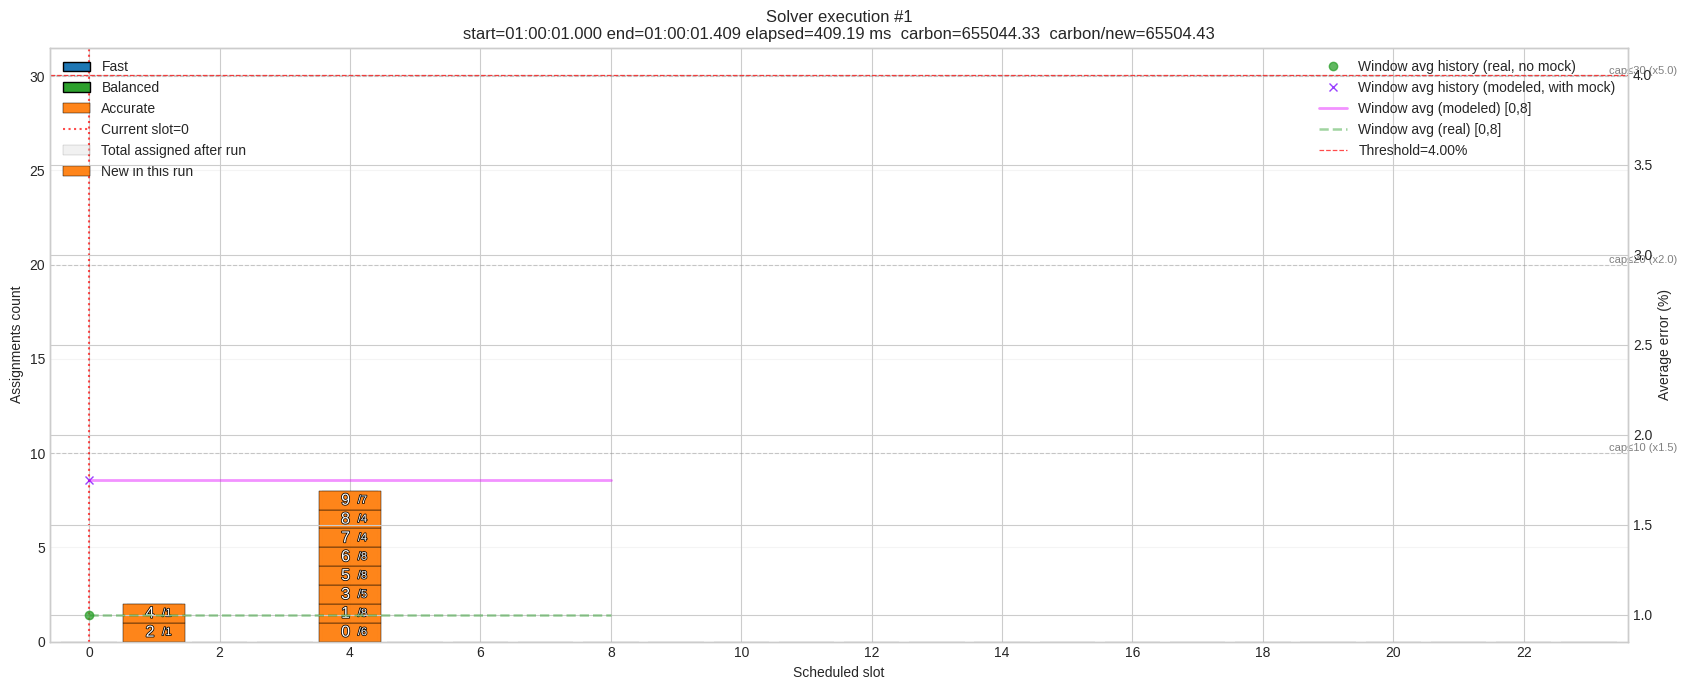

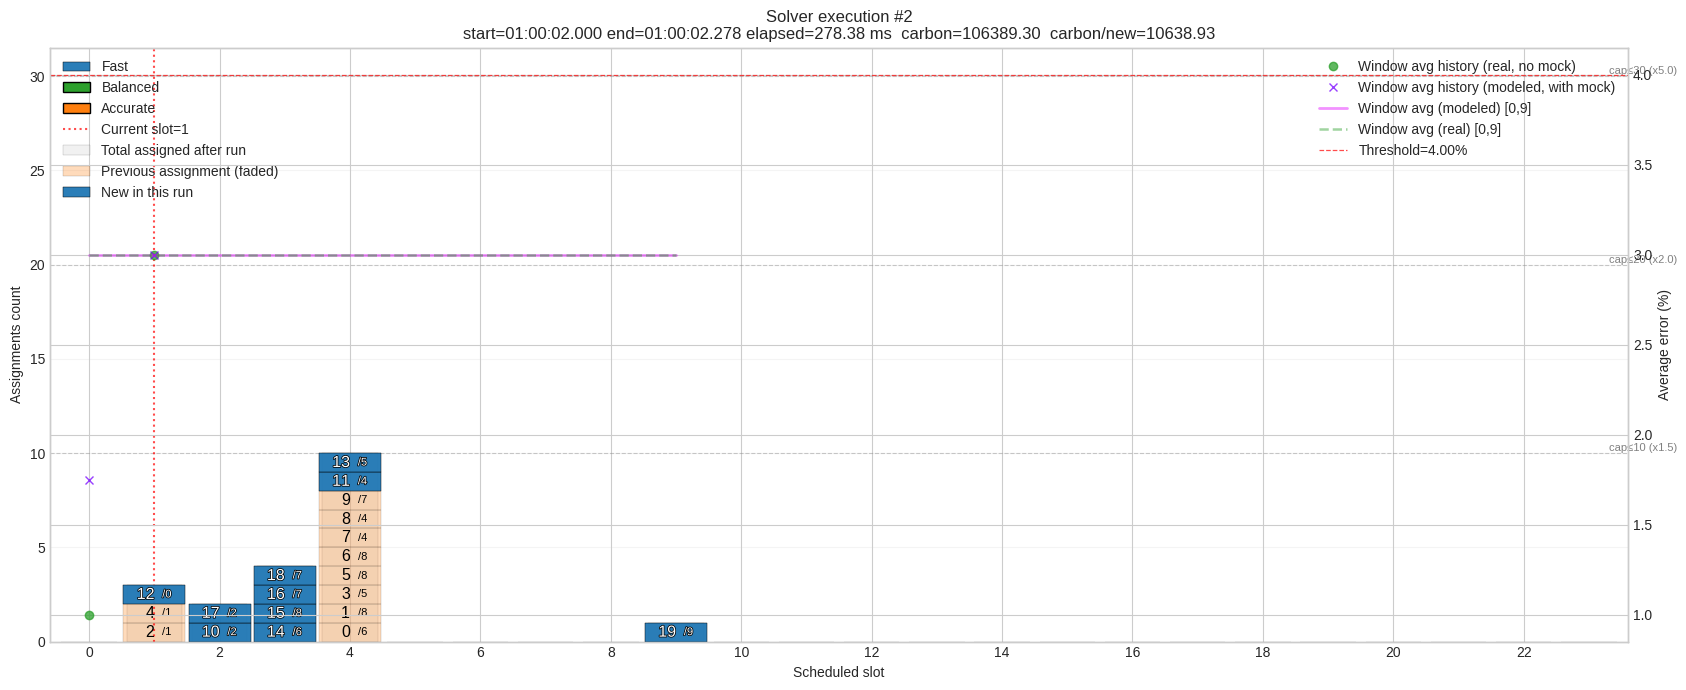

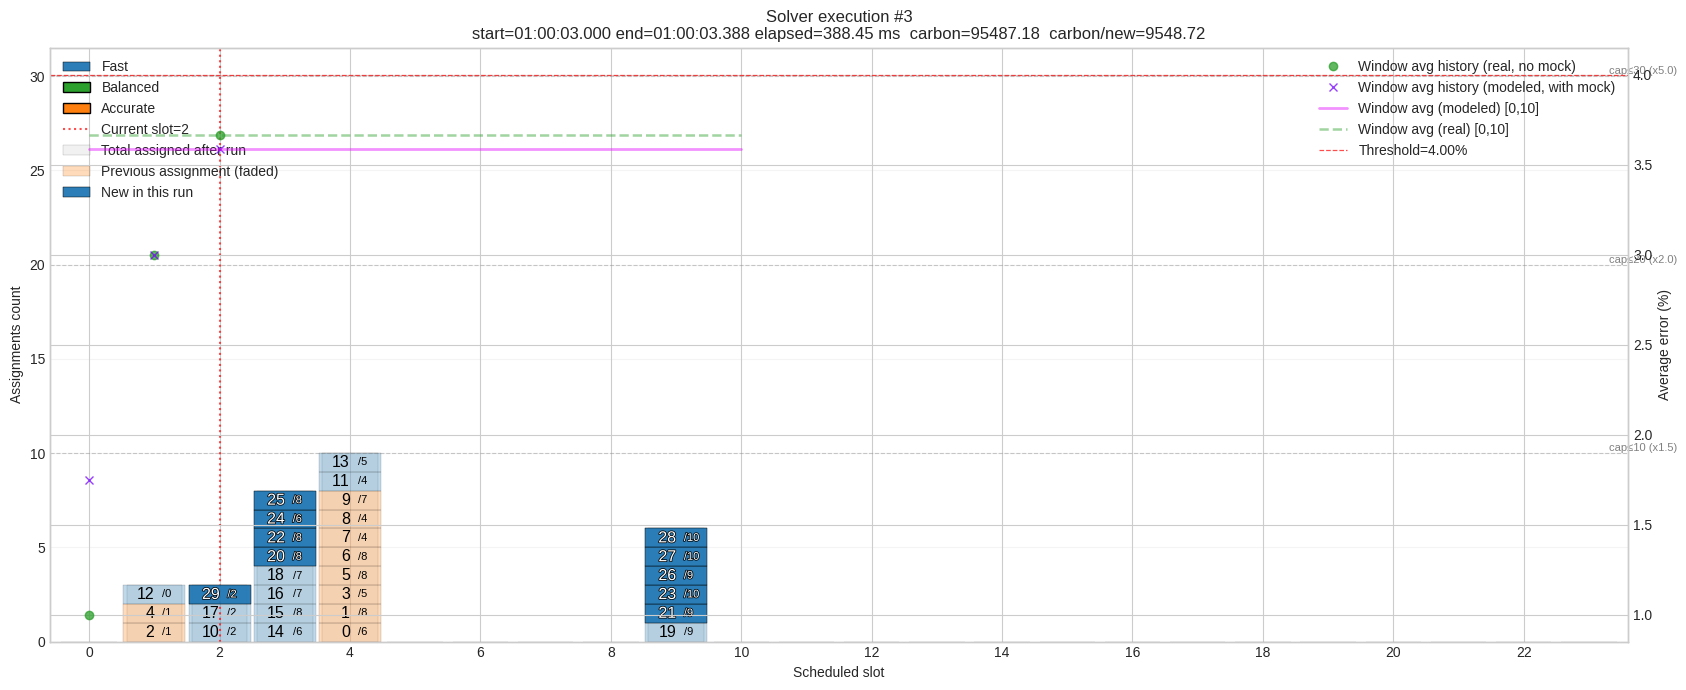

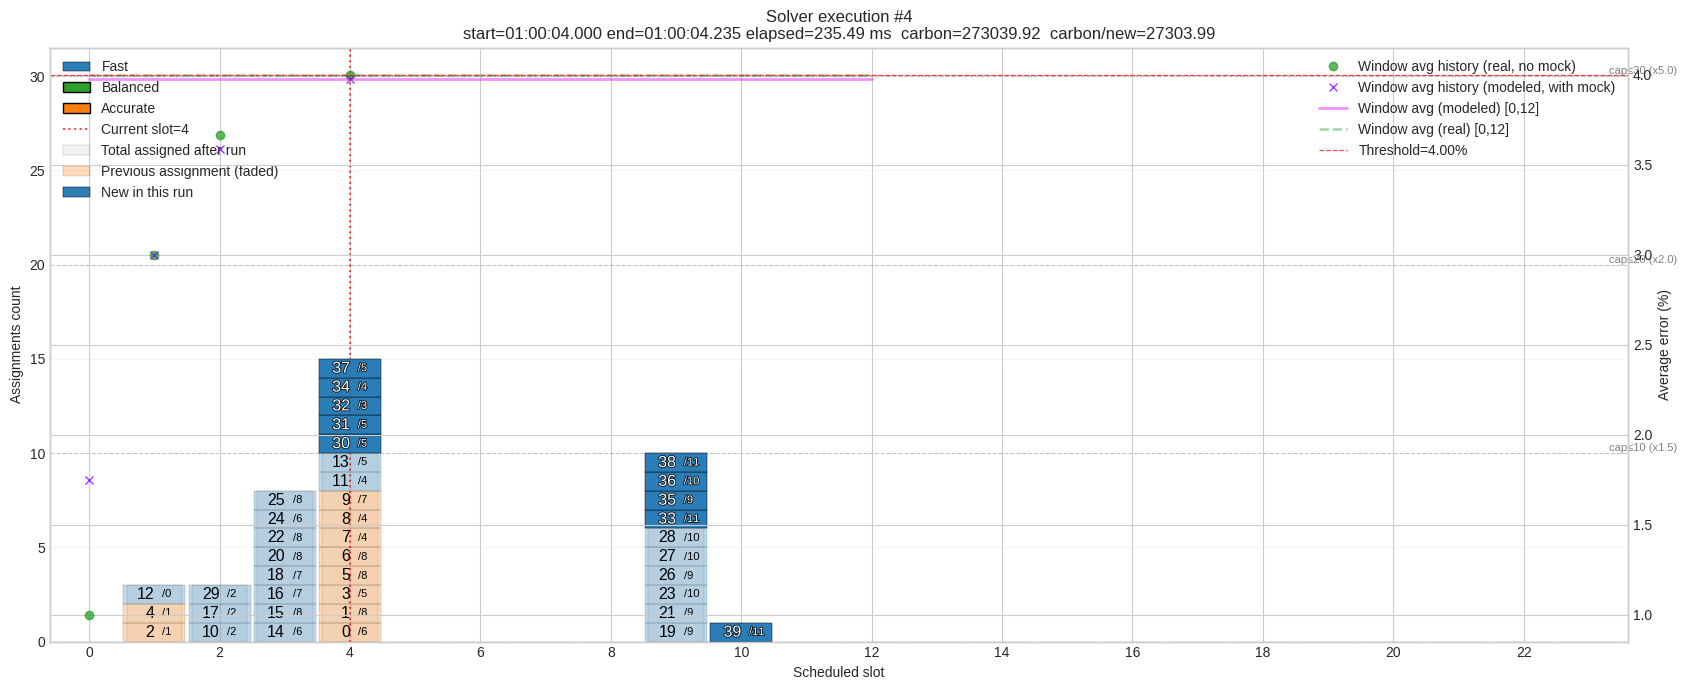

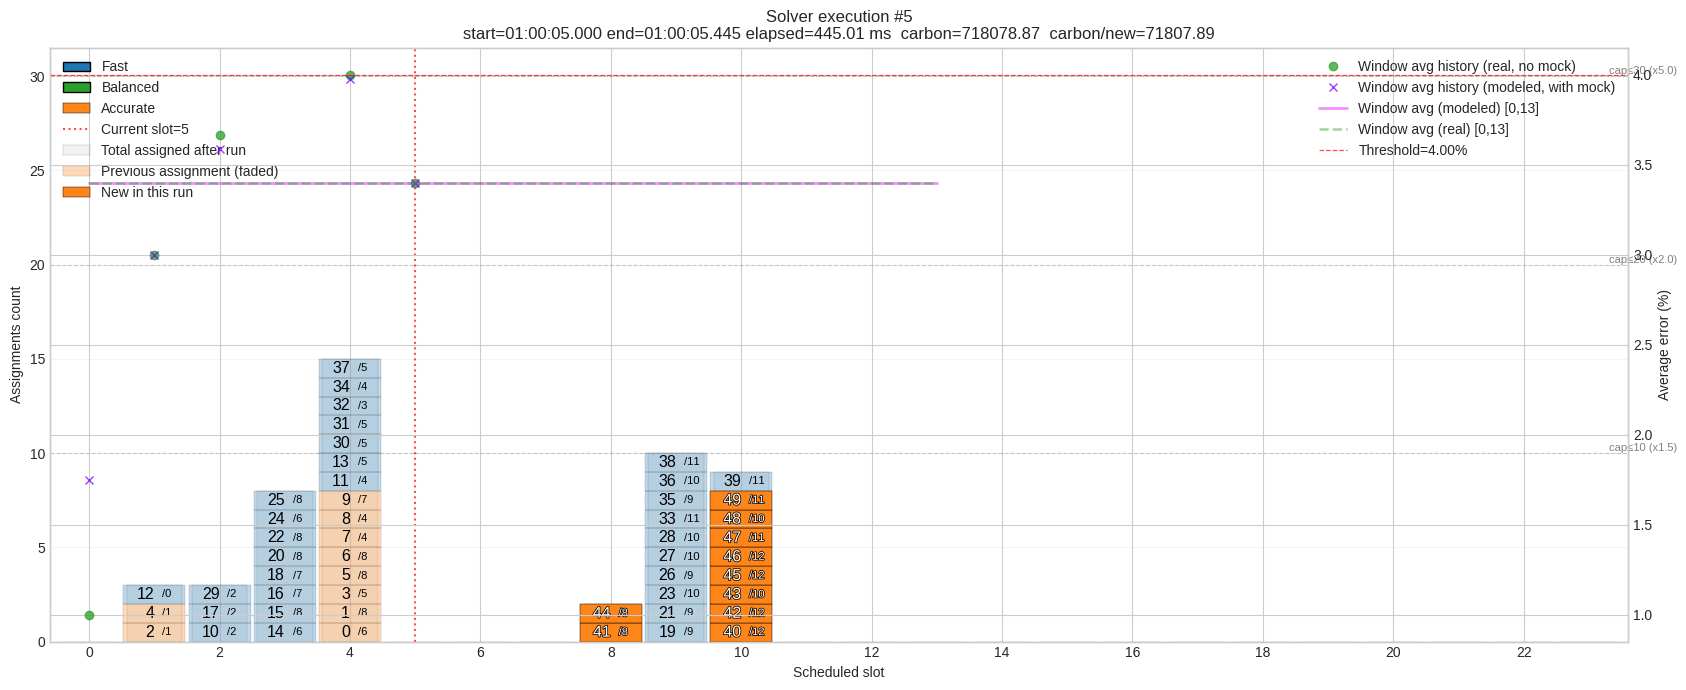

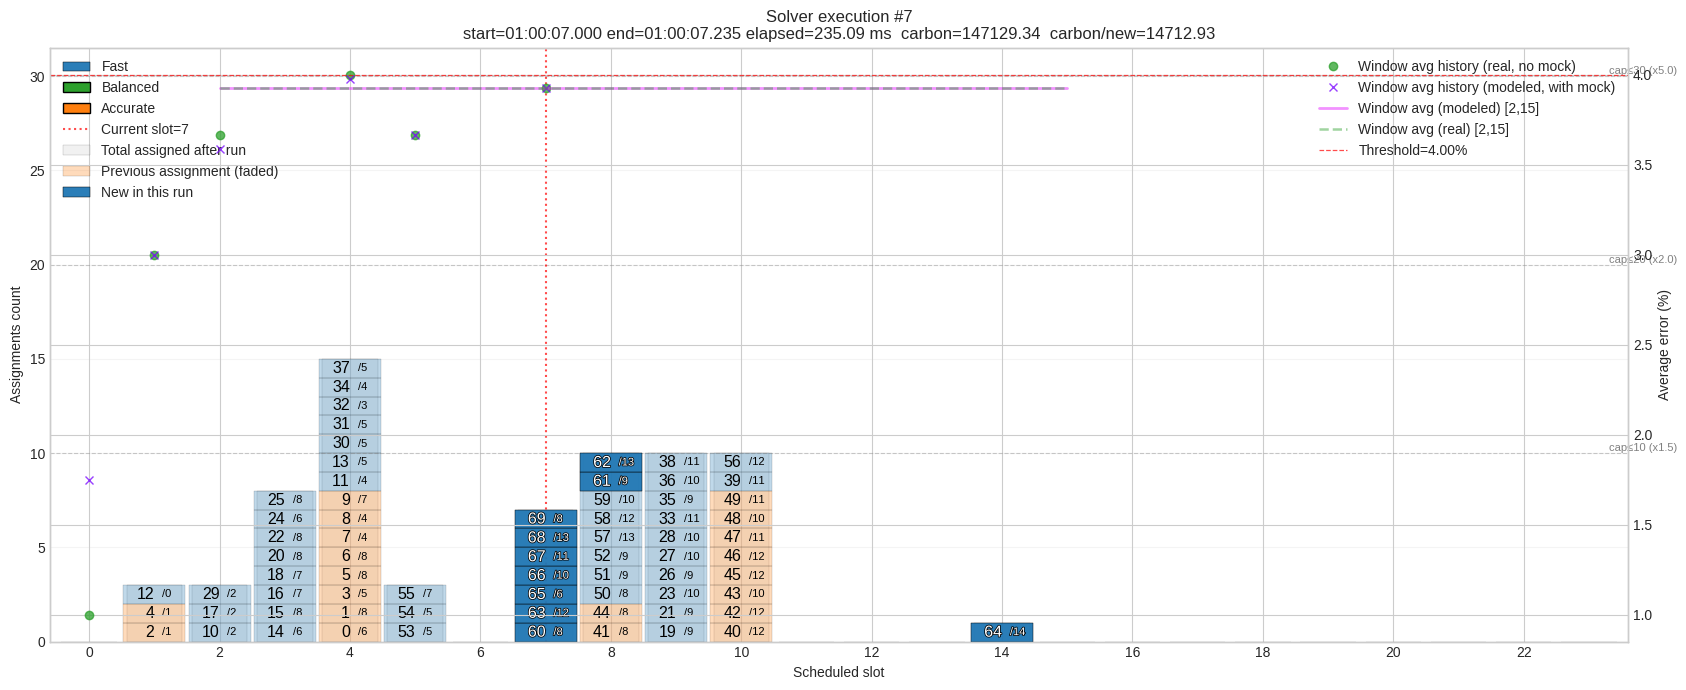

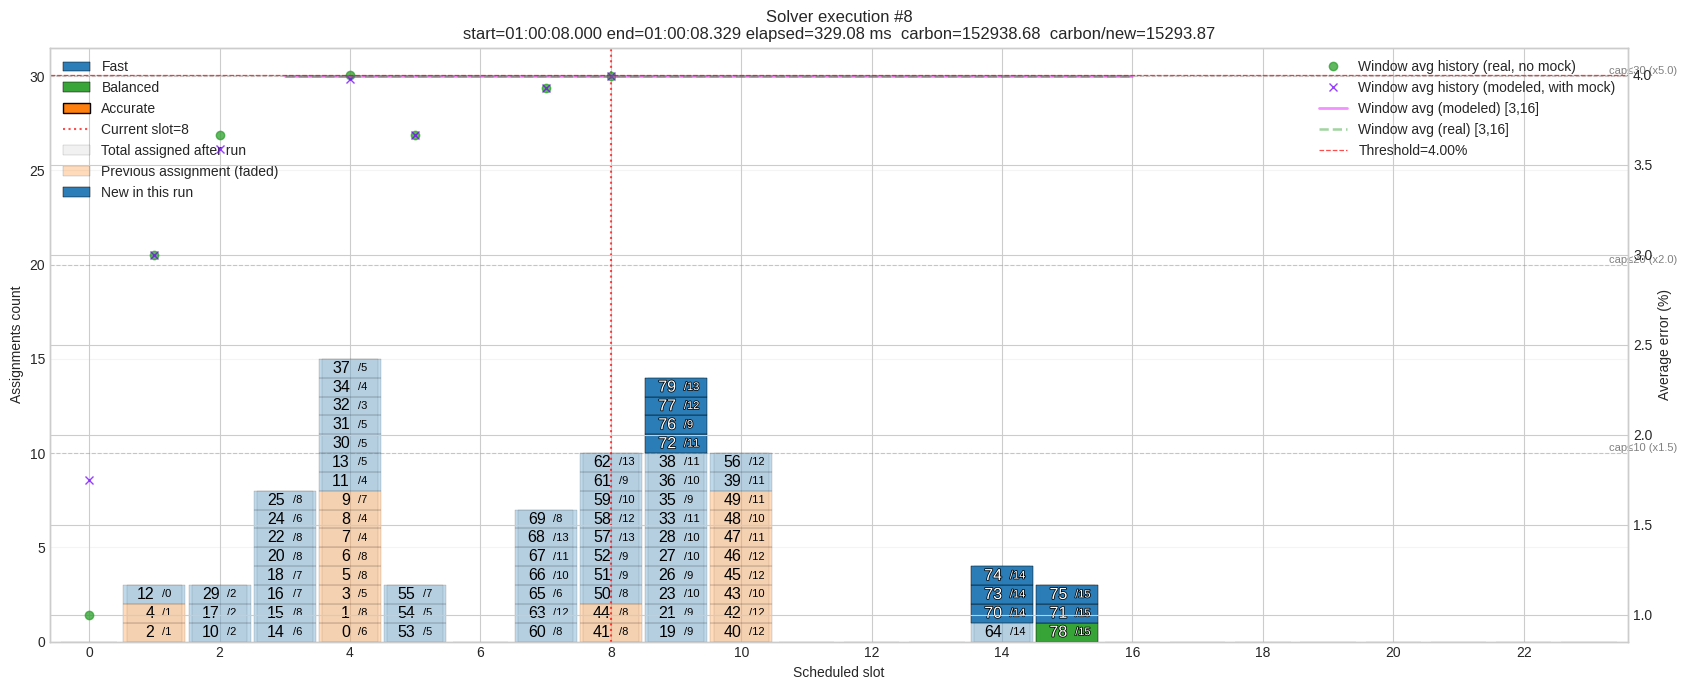

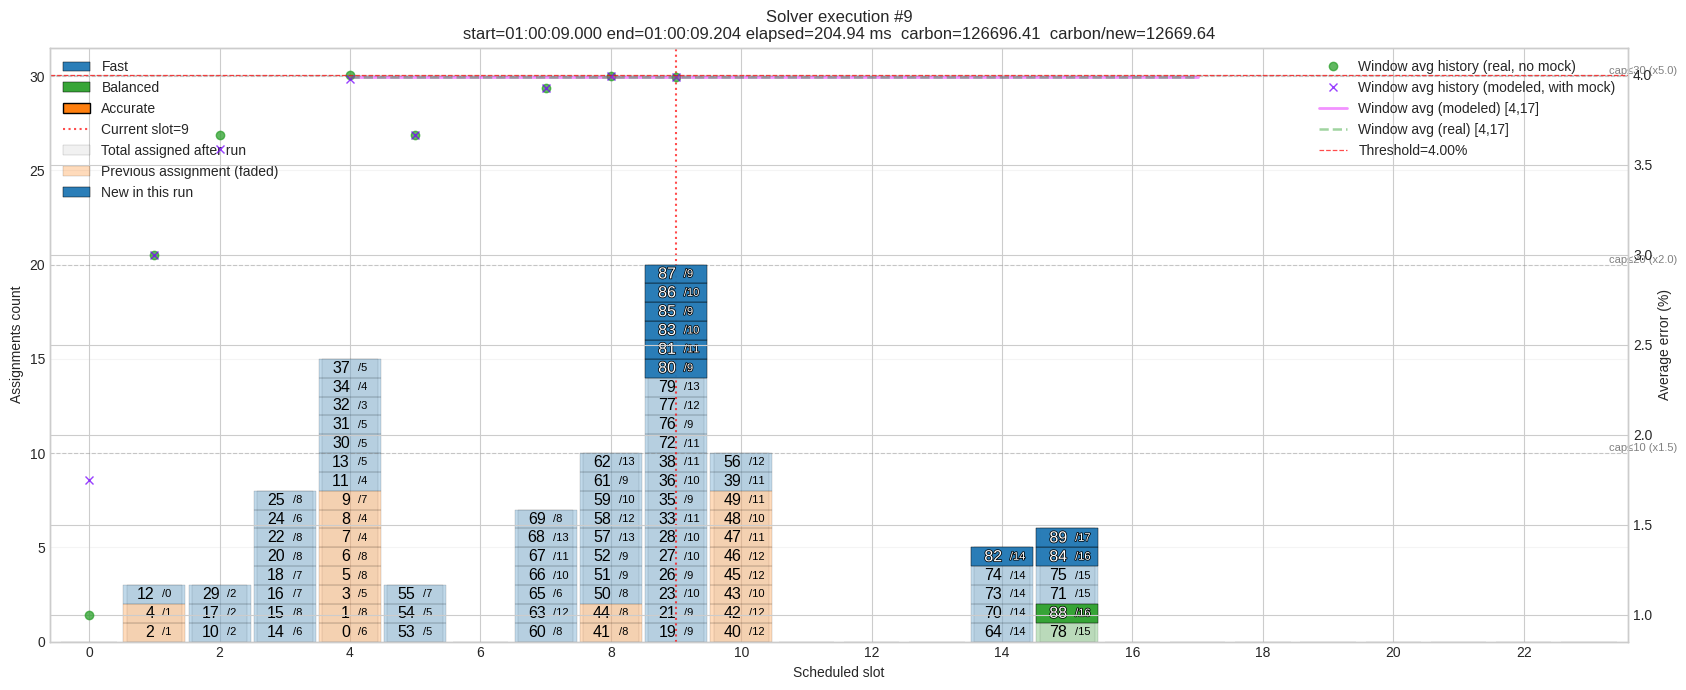

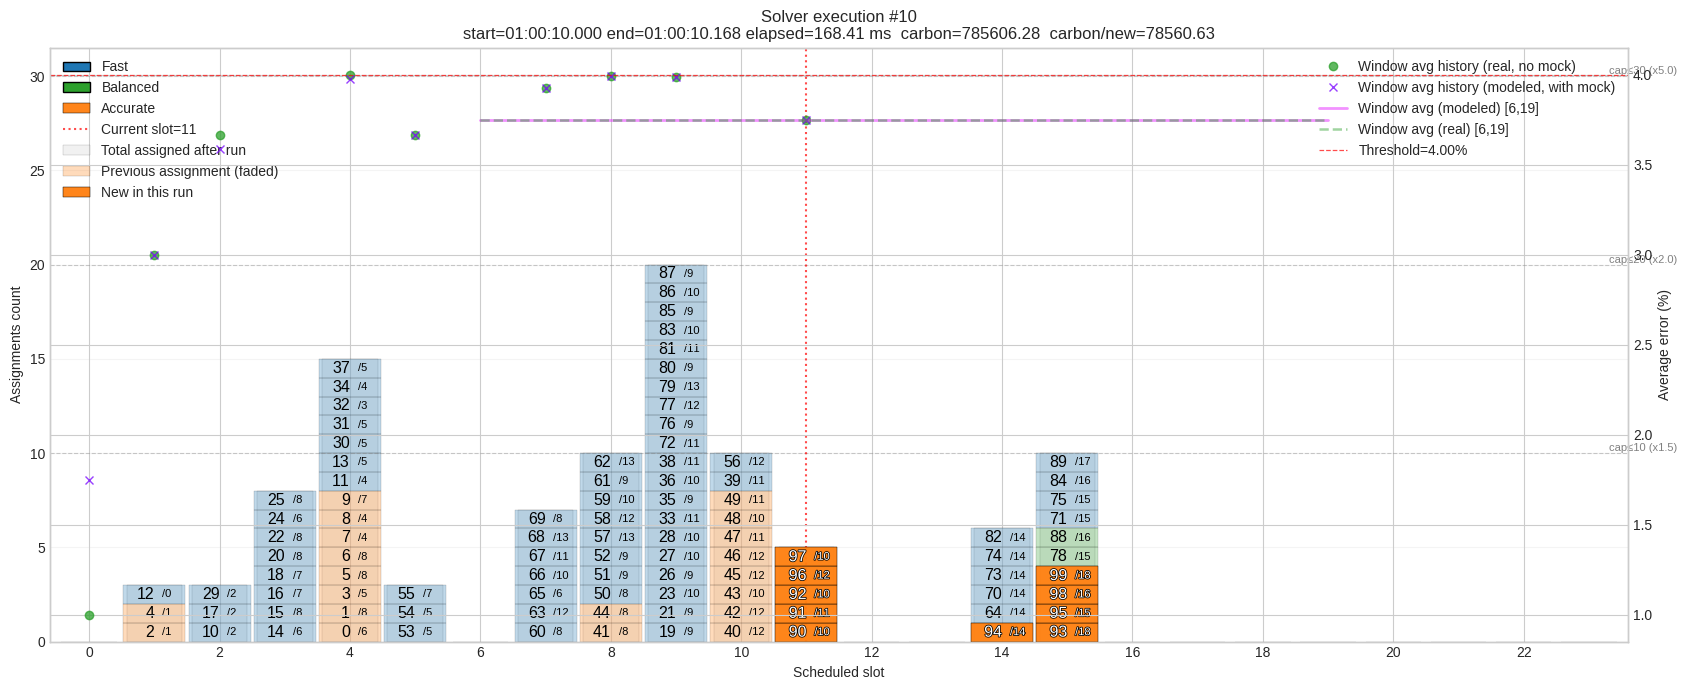

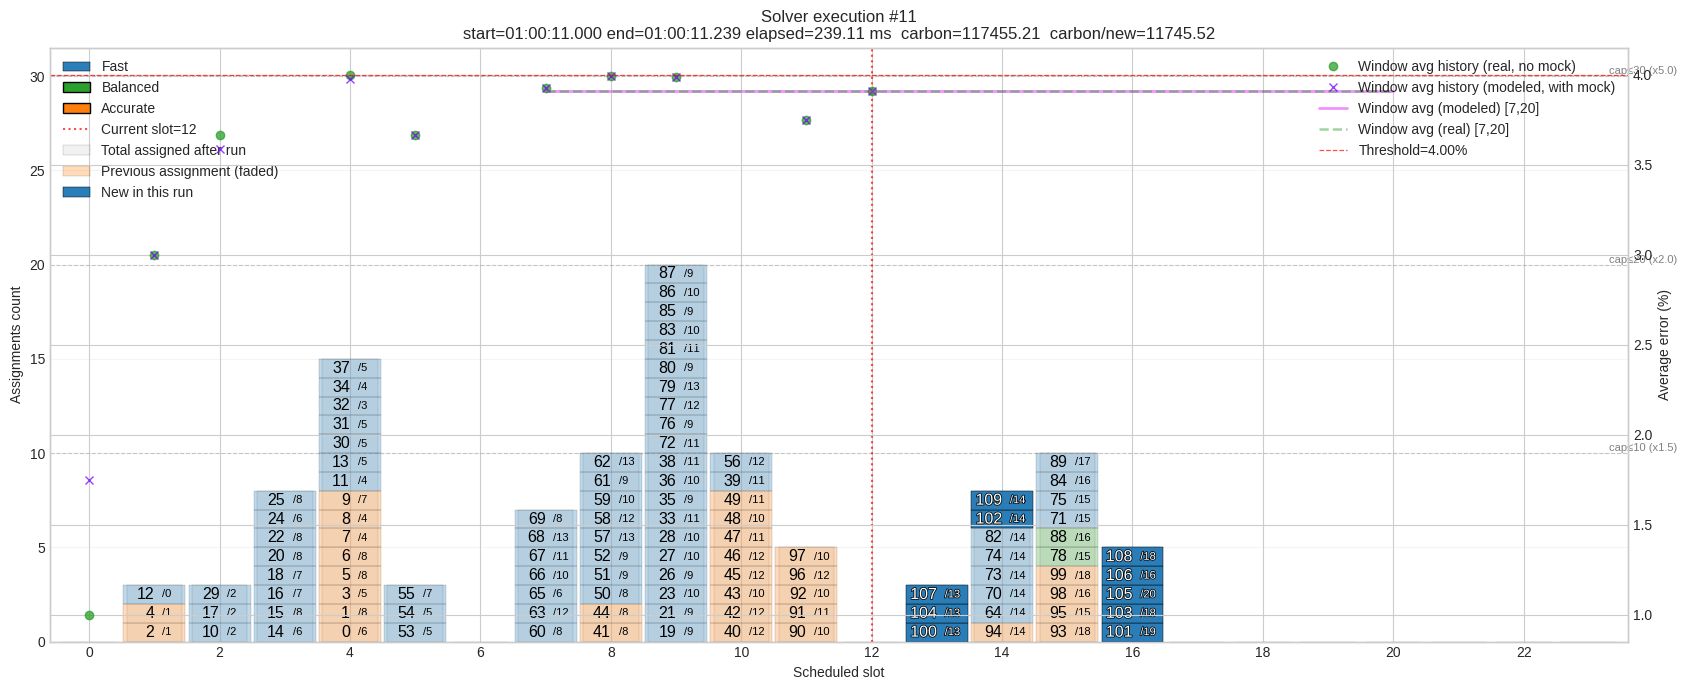

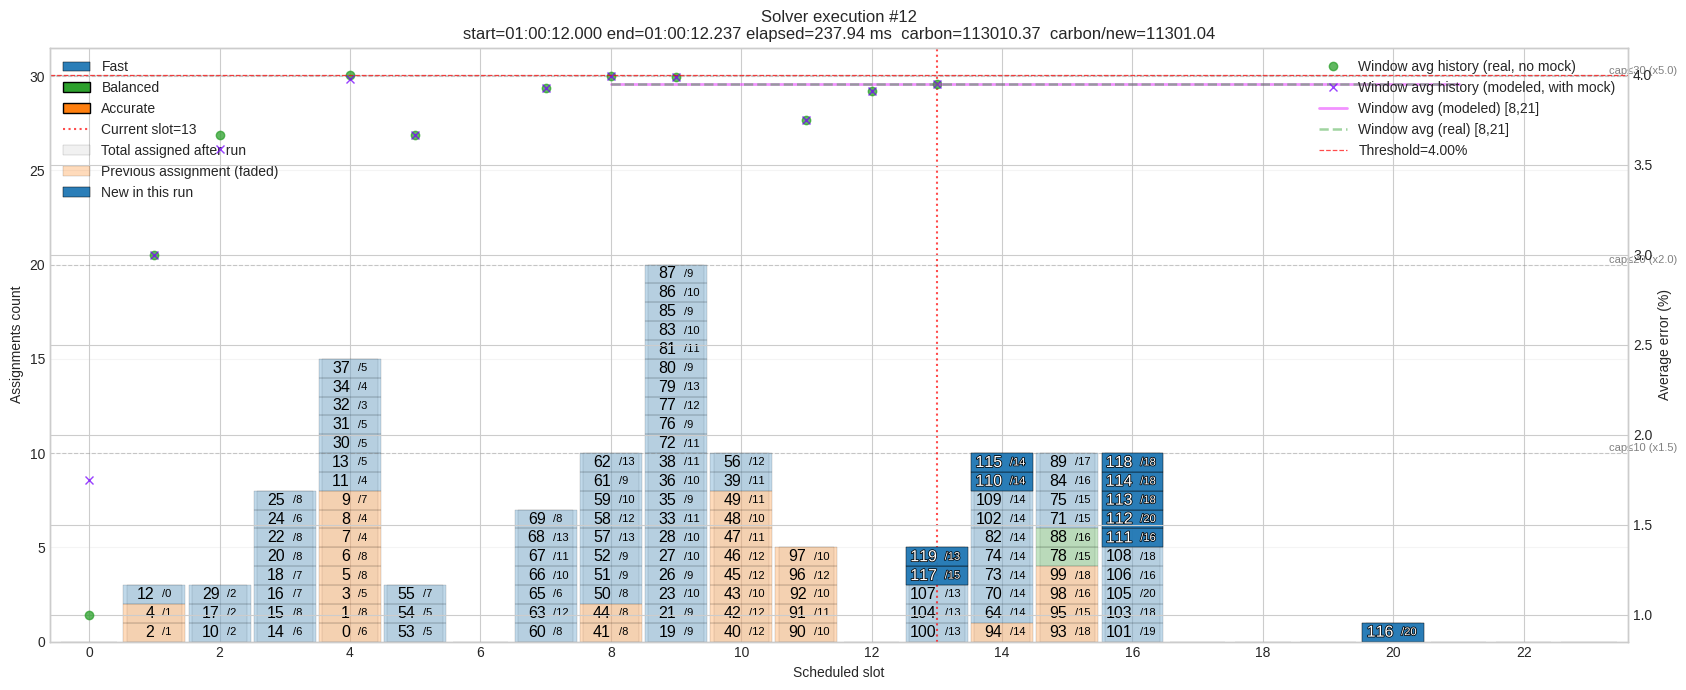

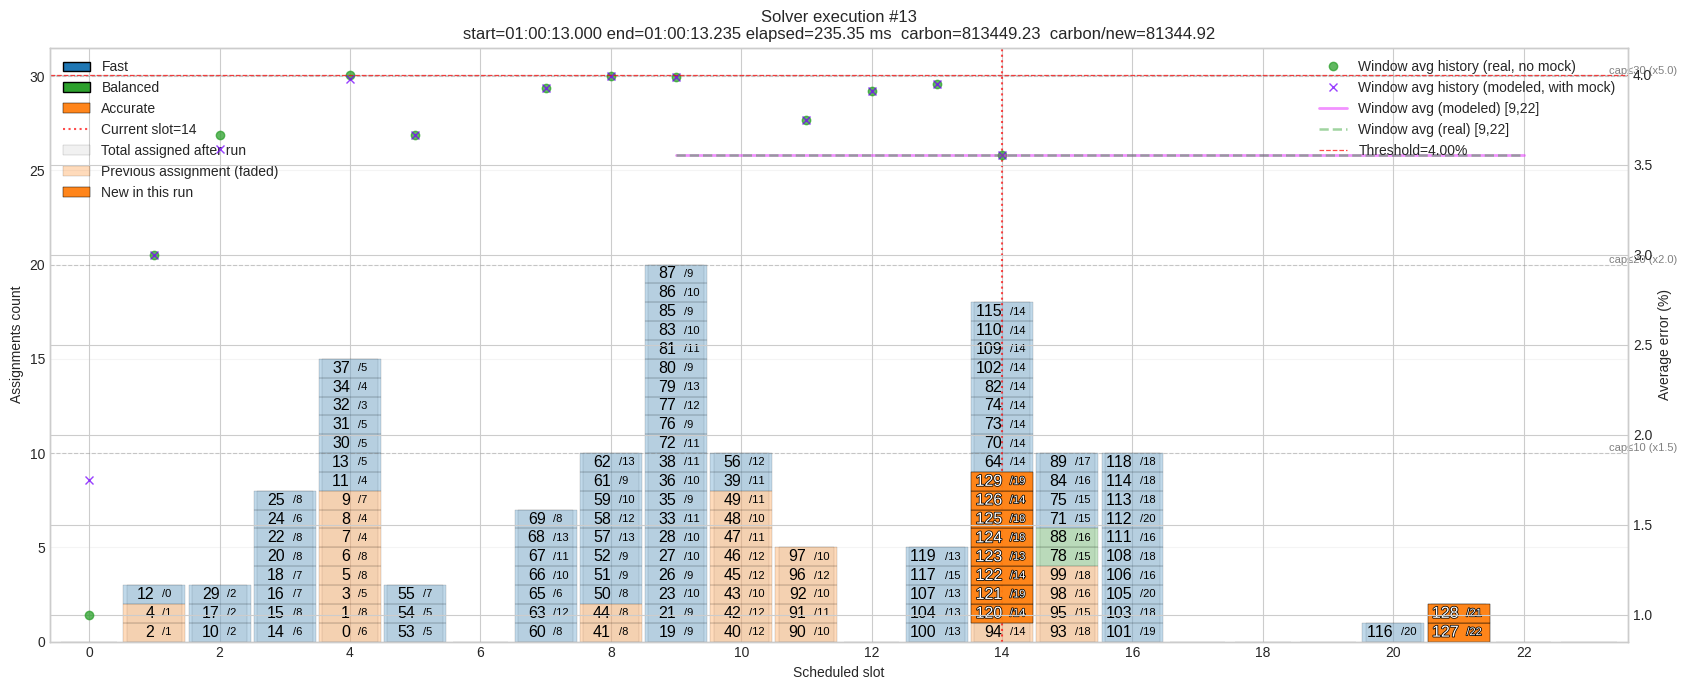

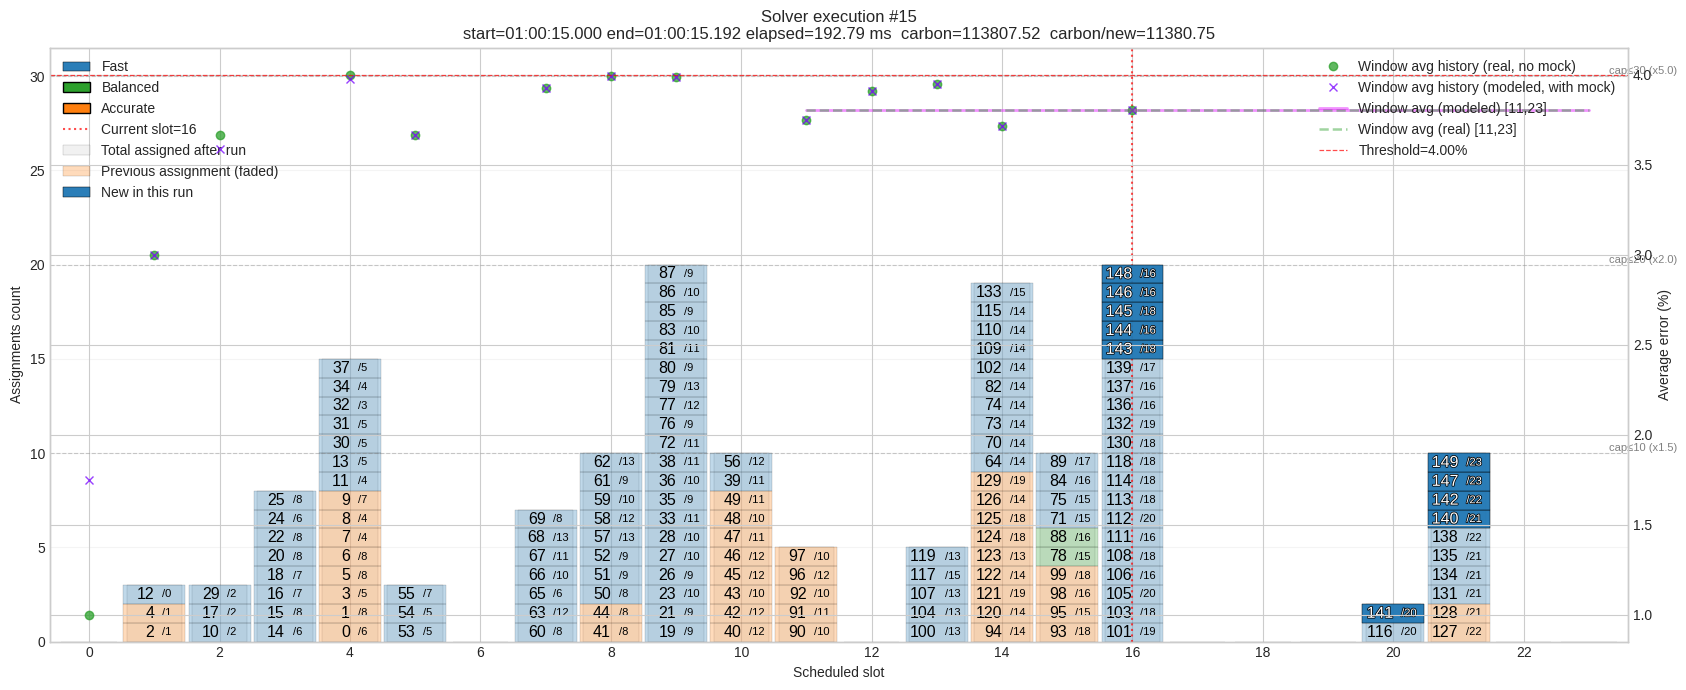

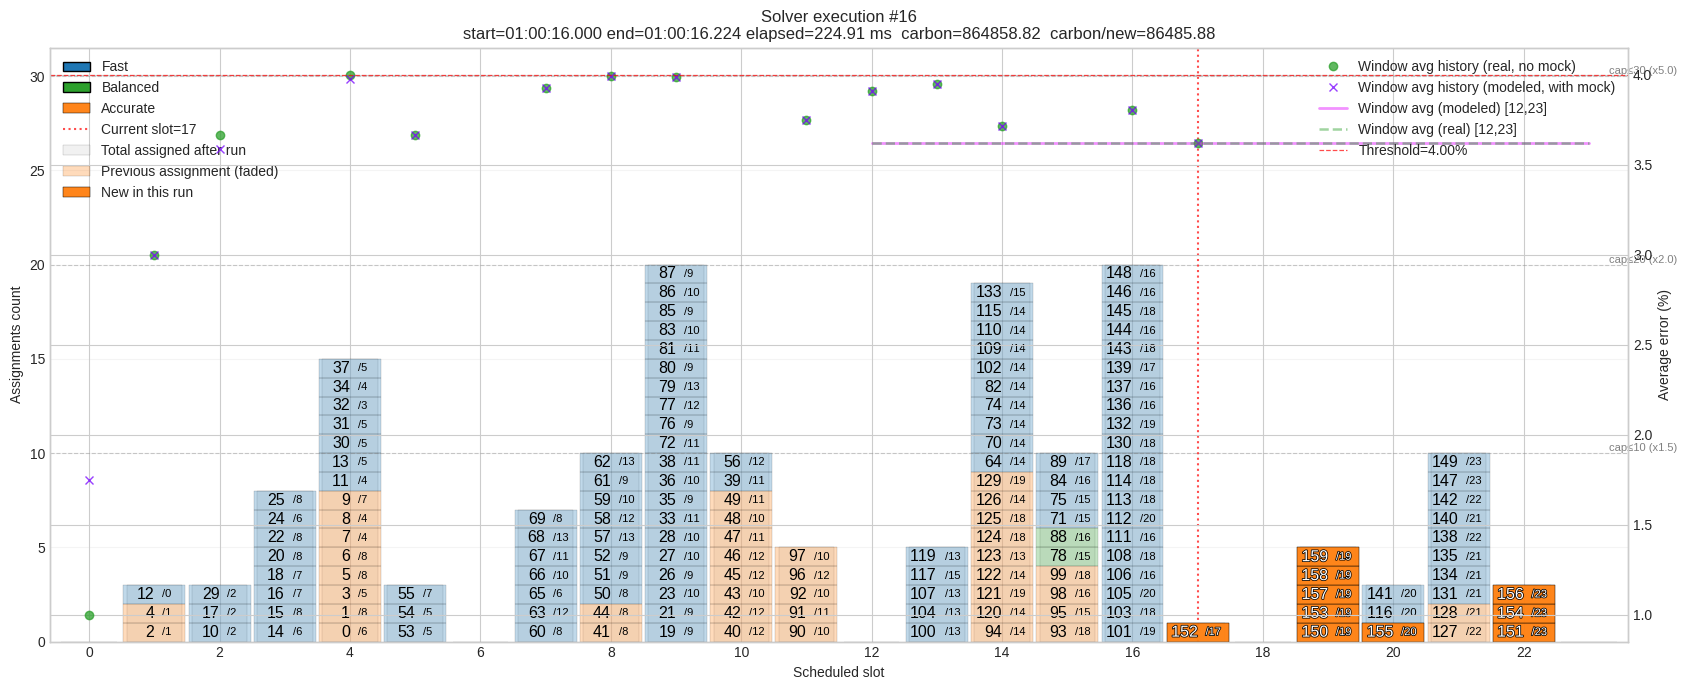

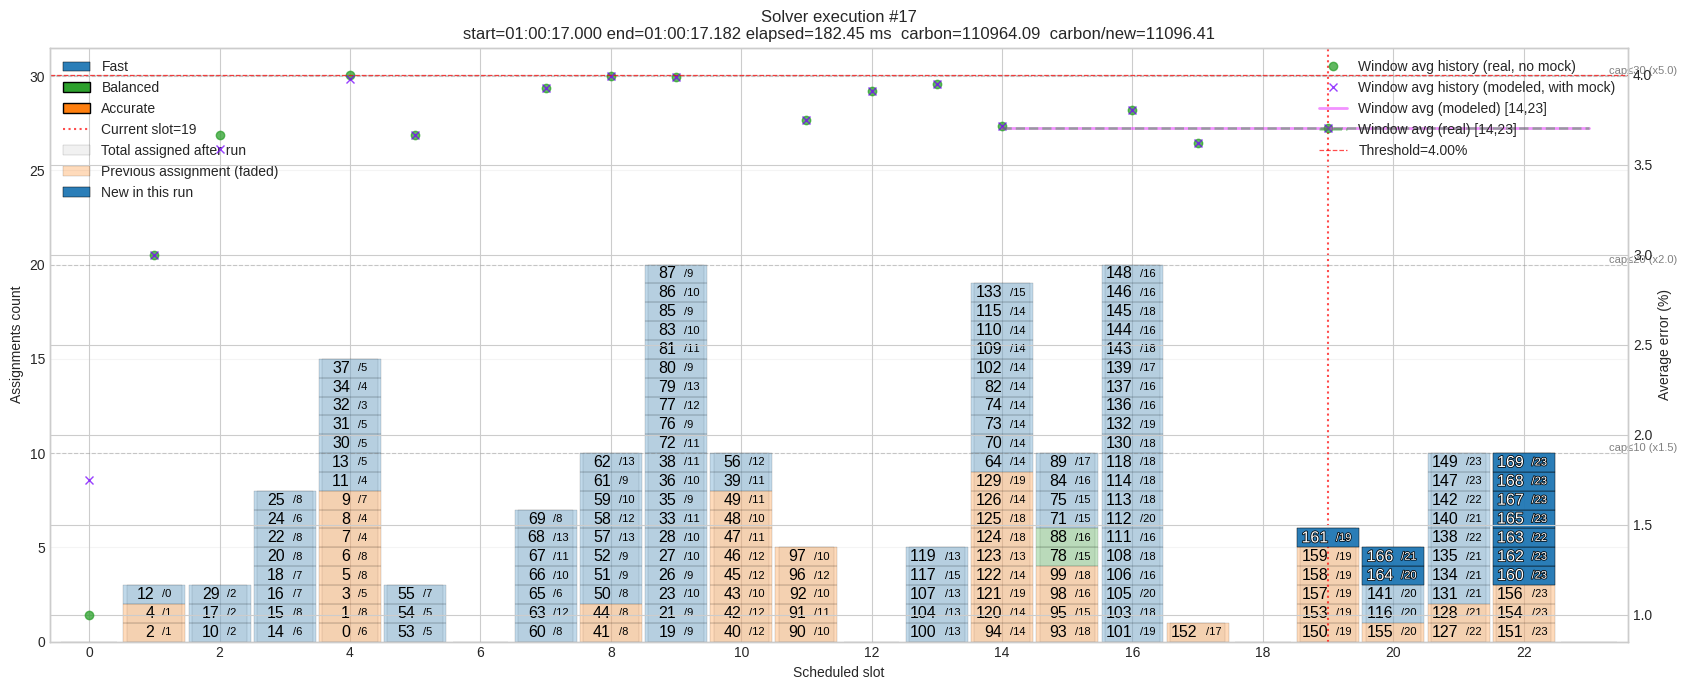

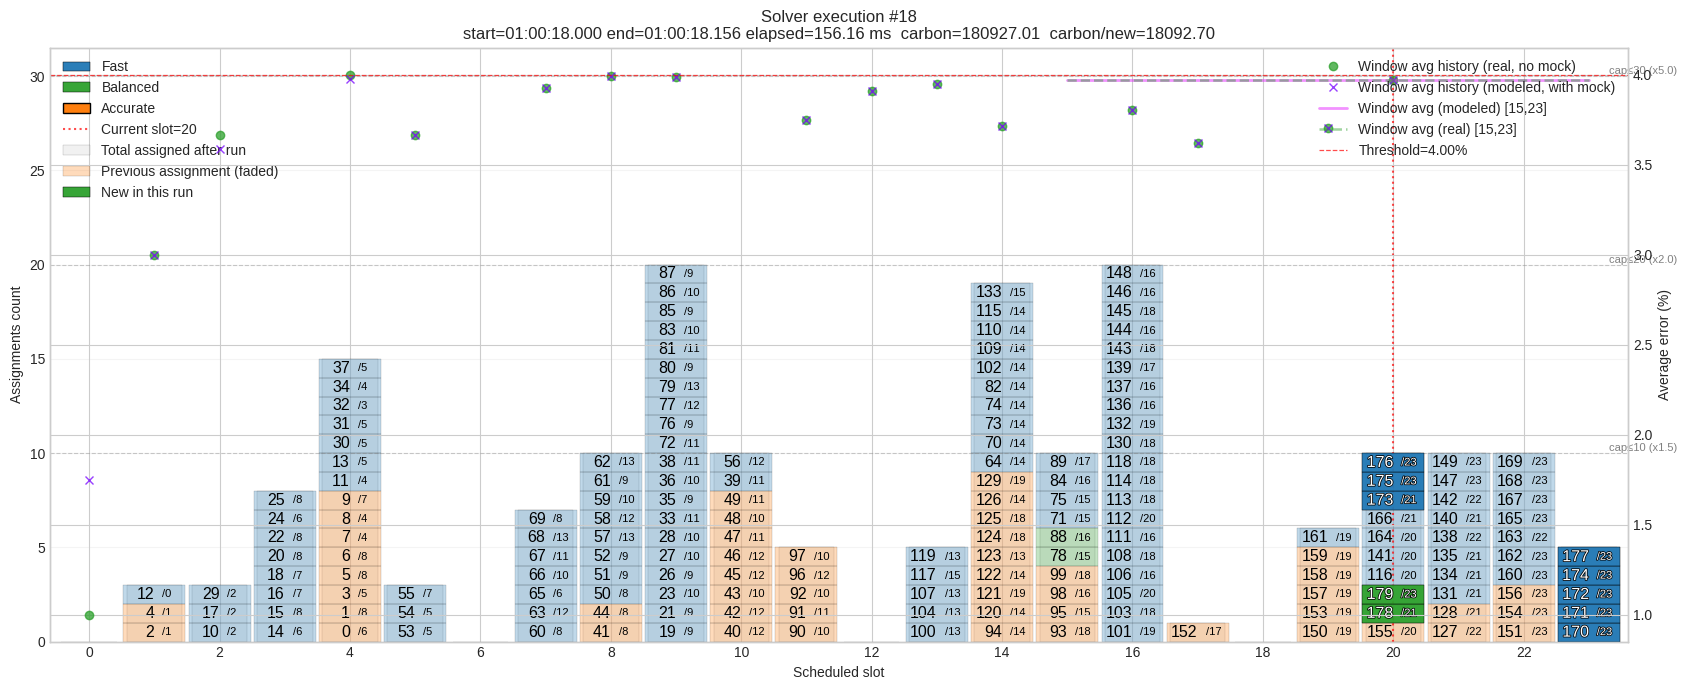

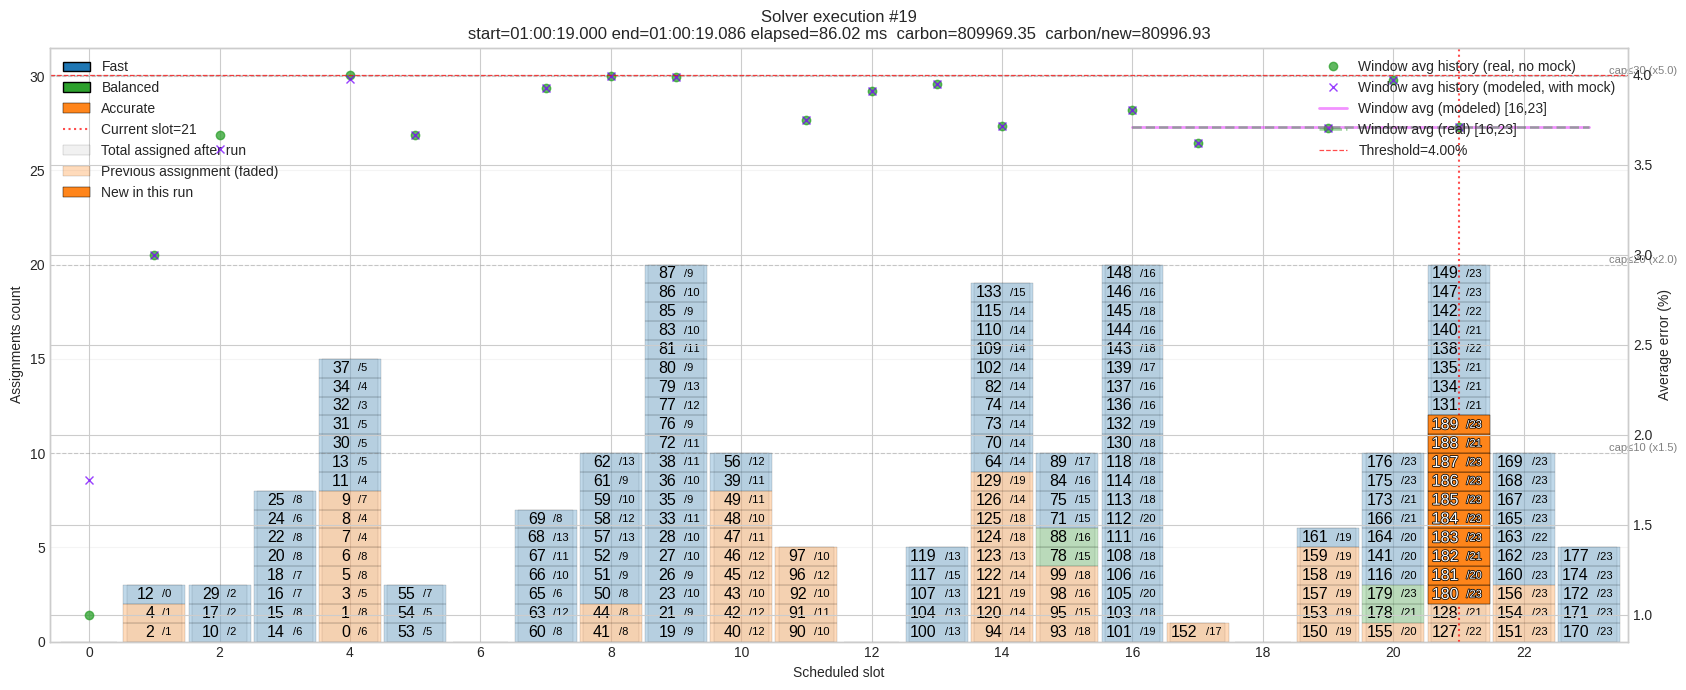

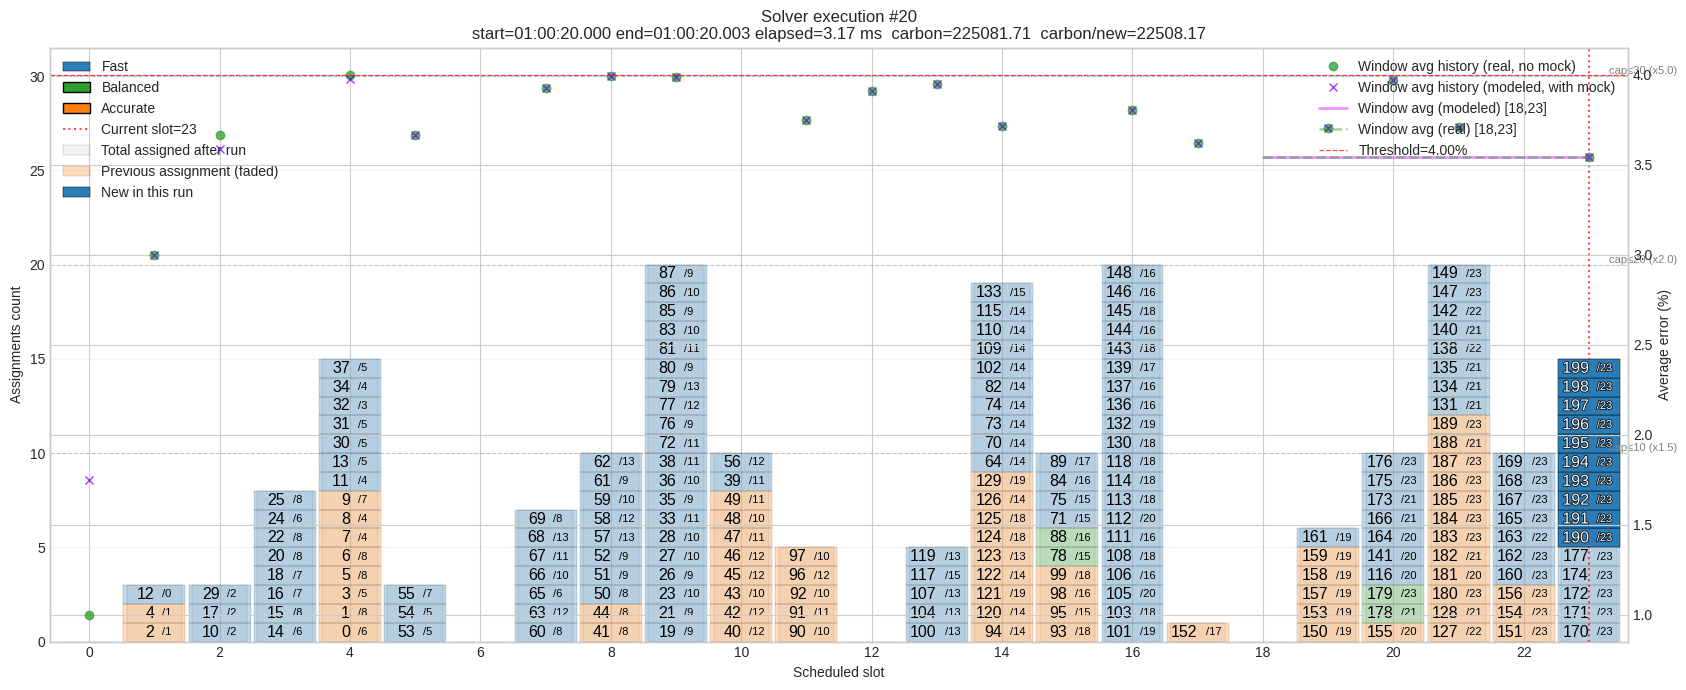

In [21]:
selected_run_ids = select_run_ids(runs_df, mode=RUN_SELECTION_MODE, target_slot=TARGET_SLOT)
if not selected_run_ids:
    raise ValueError("No runs selected with current filters.")

print(
    f"Selected {len(selected_run_ids)} runs for N={SELECTED_N}: "
    f"{selected_run_ids[:8]}{' ...' if len(selected_run_ids) > 8 else ''}"
)

for rid in selected_run_ids:
    fig = plot_solver_execution_stacked(
        run_id=rid,
        runs_df=runs_df,
        assignments_df=assignments_df,
        slot_metrics_df=None,
        strategy_colors=STRATEGY_COLORS,
    )
    plt.show()